# Import your packages

lyaDW is the name of the Lyman-alpha modeling package 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lyaDW

# Working with Thesan outputs

In [2]:
# Path to the Thesan directory
thesan_dir = '/data9/work/Aritra/Thesan/'

# Snaphots of the cartesian (xHII) and halo outputs
snap_cartesian_arr = np.array([309, 284, 259, 244, 219, 194, 169, 139, 94, 74, 54, 39, 29, 19])
snap_halo_arr = np.array([68, 63, 58, 55, 50, 45, 40, 34, 25, 21, 17, 14, 12, 10])

# Corresponding redshifts and mean xHII
thesan_z_arr = np.array([6.10, 6.40, 6.72, 6.94, 7.33, 7.78, 8.29, 9.01, 10.4, 11.19, 12.14, 12.98, 13.63, 14.35])
x_HII_mean_arr = np.array([0.8912879, 0.78929263, 0.67207265, 0.59902745, 0.484414, 0.3811102, 0.2899756, 
                           0.19686255, 0.08977191, 0.05521694, 0.029862946, 0.016563926, 0.010203759, 0.0054941336])


# Define a few parameters

In [32]:
output_dir = './output/'
target_z = 9.01                    # redshift to run the pipeline at
z_end = 5.5                        # redshift where neutral IGM ends

# Using a higher mass for selecting fewer galaxies so that we get faster calculations in this example. 
# Ideally, one should use this package in a .py code, instead of a .ipynb file if they have large number of galaxies
M_h_min = 1e10                      # minimum halo mass (M_Sun)  

f_vel_out = 0.0                    # outflow velocity = f_vel_out * sigma_v
save = True                        # save intermediate outputs to disk

# Defining the simulation

We are showing an example by using the outputs at z = 9.01. Here we define the simulation. For now we have tested using Thesan and Limfast.

We define the simulation by using lyaDW.Simulation class. If using Thesan, then providing the corresponding cartesian and halo snapshots (as an array) is necessary. One can also define it for all the redshifts, as we are doing below.

In [35]:
sim = lyaDW.Simulation(redshifts=thesan_z_arr,
                       h=0.6774,
                       Omega_m=0.3089,
                       Omega_l=1-0.3089,
                       Omega_b=0.0486,
                       simname='Thesan', 
                       snap_cartesian_arr=snap_cartesian_arr,
                       snap_halo_arr=snap_halo_arr)

In [36]:
print(sim)

Simulation('Thesan', z=[6.10..14.35], h=0.6774, Omega_m=0.3089)


In [37]:
print(sim.cosmo)

{'h': 0.6774, 'Omega_m': 0.3089, 'Omega_l': 0.6911, 'Omega_b': 0.0486, 'Omega_m_h2': 0.141745177764, 'Omega_b_h2': 0.022301118935999998}


# Load the HII fraction cube

For ease of use, one can use the lyaDW.io module to load in data cubes if they are working with Thesan or Limfast outputs. Otherwise, their own 3D array will also work.

In [19]:
# =============================================================================
# Load data and compute bubble sizes
# =============================================================================
 
# Automatically sets sim.get_mean_xHI(target_z)

HII_cube, BoxSize = lyaDW.io.thesan.load_HII_cube(thesan_dir, sim, z=target_z)
print(f"HII cube shape: {HII_cube.shape}, BoxSize: {BoxSize:.1f} ckpc/h")

HII cube shape: (512, 512, 512), BoxSize: 64691.7 ckpc/h


# Load the galaxies

positions, halo masses, and stellar masses along with their star-formation rates and velocity dispersion

In [21]:
positions, halo_masses, stellar_masses, sfr = lyaDW.io.thesan.load_galaxies(thesan_dir, 
                                                                       sim, 
                                                                       z=target_z, 
                                                                       M_h_min=M_h_min)

# This computes the velocity dispersion from the halo mass and redshift using an analytical expression (Barkana & Loeb 2001)
sigma_v = lyaDW.utils.galaxy.compute_sigma_v(halo_masses, z=target_z, h=sim.h)
 
print(f"Number of galaxies: {len(halo_masses)}")

Number of galaxies: 2366


# Compute the bubble sizes

In [22]:
R_ion = lyaDW.core.bubble_sizes.compute_bubble_sizes(positions, HII_cube, BoxSize,
                                                     sim=sim, z=target_z,
                                                     xHII_threshold=0.5,
                                                     boxsize_units='ckpc/h',
                                                     save=save, savepath=output_dir)

R_ion is in  Mpc
Saved bubble sizes to: ./output/bubble_sizes_Thesan_z9.01.h5


In [23]:
R_ion

array([4.29003906, 4.29003906, 4.10351562, ..., 2.23828125, 2.05175781,
       2.05175781], shape=(2366,))

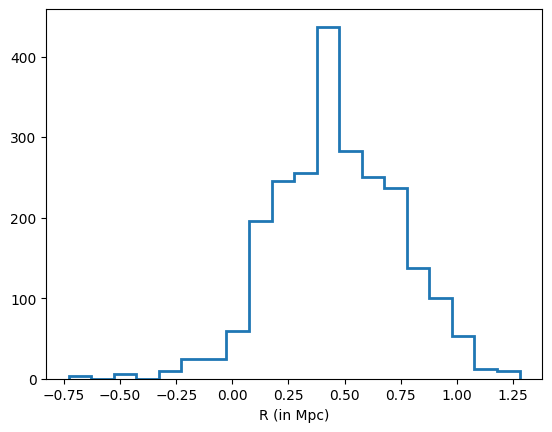

In [24]:
plt.hist(np.log10(R_ion[R_ion>0]), bins=20, histtype='step', lw=2)
plt.xlabel('R (in Mpc)')
plt.show()

In [25]:
# Keep only galaxies with non-zero bubble size
non_zero = R_ion > 0
R_ion = R_ion[non_zero]
halo_masses = halo_masses[non_zero]
stellar_masses = stellar_masses[non_zero]
sfr = sfr[non_zero]
sigma_v = sigma_v[non_zero]
 
print(f"Galaxies with R_ion > 0: {non_zero.sum()}")
print(f"R_ion range: {R_ion.min():.2f} — {R_ion.max():.2f} Mpc")

Galaxies with R_ion > 0: 2345
R_ion range: 0.19 — 19.03 Mpc


# Computing the starting redshift of the neutral IGM

In [26]:
# =============================================================================
# Compute IGM starting redshifts
# =============================================================================
 
z_beg = lyaDW.core.igm_redshift.compute_z_beg(R_ion, 
                                              z_s=target_z, 
                                              sim=sim,
                                              z_end=z_end, 
                                              save=save, 
                                              savepath=output_dir)
 
print(f"z_beg range: {z_beg.min():.3f} — {z_beg.max():.3f}")

Closest redshift =  9.01
Saved z_beg to: ./output/z_beg_Thesan_z9.01.h5
z_beg range: 8.935 — 9.009


# Compute the Lyman-$\alpha$ damping wing optical depths

In [27]:
# =============================================================================
# Compute damping wing optical depths
# =============================================================================
 
# mean_xHI is fetched automatically from sim
tau_dw, delta = lyaDW.core.optical_depth.compute_tau(z_beg, 
                                                     z_s=target_z, 
                                                     sim=sim, 
                                                     z_end=z_end, 
                                                     n_quad=64, 
                                                     save=save, 
                                                     savepath=output_dir)
 
print(f"tau_dw shape: {tau_dw.shape}")
print(f"mean x_HI used: {sim.get_mean_xHI(target_z):.4f}")

Saved tau_DW to: ./output/tau_dw_Thesan_z9.01.h5
tau_dw shape: (2345, 2001)
mean x_HI used: 0.8031


# Compute the Lyman-$\alpha$ transmission coefficients

In [29]:
# =============================================================================
# Compute transmission coefficients
# =============================================================================
 
T_alpha = lyaDW.core.transmission.compute_T_alpha(tau_dw, delta, 
                                                  z_s=target_z, 
                                                  sigma_v=sigma_v, 
                                                  SFR=sfr, sim=sim, 
                                                  f_vel_out=f_vel_out, 
                                                  save=save, 
                                                  savepath=output_dir)
 
print(f"Median T_alpha: {np.median(T_alpha):.4f}")

Saved T_alpha to: ./output/T_alpha_Thesan_z9.01_fvelout0.0.h5
Median T_alpha: 0.0527


#### The rest of the notebook is optional. It was designed particularly to calculate EWs (which is incorrect now) and Ly-alpha EW fractions (using a specific approach).

In [31]:
# =============================================================================
# Compute equivalent widths and luminosities
# =============================================================================
 
lum_results = lyaDW.core.luminosity.compute_luminosities(T_alpha, delta,
                                                         sigma_v=sigma_v,
                                                         SFR=sfr,
                                                         sim=sim,
                                                         z_s=target_z,
                                                         f_vel_out=f_vel_out,
                                                         b=-1.7,
                                                         save=save, savepath=output_dir)
 
REW = lum_results['REW']
L_UV_nu = lum_results['L_UV_nu']
L_alpha_int = lum_results['L_alpha_int']
L_alpha_trans = lum_results['L_alpha_trans']

Saved equivalent widths and luminosities to: ./output/lum_rew_Thesan_z9.01_fvelout0.0_b1.7.h5


# Compute Lyman-$\alpha$ EW fractions

In [38]:
# =============================================================================
# Compute Lyman-alpha emitter fraction (Tang+24 anchored)
# =============================================================================
 
# Run the same pipeline at z=6 for the Tang+24 anchored fractions
z_ref = 6.10
 
HII_cube_z6, BoxSize_z6 = lyaDW.io.thesan.load_HII_cube(thesan_dir, sim, z=z_ref)

pos_z6, M_h_z6, M_st_z6, sfr_z6 = lyaDW.io.thesan.load_galaxies(thesan_dir, sim, z=z_ref, M_h_min=M_h_min)

sigma_v_z6 = lyaDW.utils.galaxy.compute_sigma_v(M_h_z6, z=z_ref, h=sim.h)
 
R_ion_z6 = lyaDW.core.bubble_sizes.compute_bubble_sizes(pos_z6, HII_cube_z6, 
                                                        BoxSize_z6, sim=sim, 
                                                        z=z_ref, 
                                                        xHII_threshold=0.5, 
                                                        boxsize_units='ckpc/h')
 
non_zero_z6 = R_ion_z6 > 0
R_ion_z6 = R_ion_z6[non_zero_z6]
sfr_z6 = sfr_z6[non_zero_z6]
sigma_v_z6 = sigma_v_z6[non_zero_z6]
 
z_beg_z6 = lyaDW.core.igm_redshift.compute_z_beg(R_ion_z6, z_s=z_ref, sim=sim, z_end=z_end)

tau_dw_z6, delta_z6 = lyaDW.core.optical_depth.compute_tau(z_beg_z6, z_s=z_ref, sim=sim, z_end=z_end)

T_alpha_z6 = lyaDW.core.transmission.compute_T_alpha(tau_dw_z6, delta_z6, z_s=z_ref, 
                                                     sigma_v=sigma_v_z6, 
                                                     SFR=sfr_z6, sim=sim, 
                                                     f_vel_out=f_vel_out)
 
# UV magnitudes for the magnitude cut
lum_z6   = lyaDW.core.luminosity.compute_luminosities(T_alpha_z6, delta_z6,
                                                      sigma_v=sigma_v_z6, SFR=sfr_z6,
                                                      sim=sim, z_s=z_ref, f_vel_out=f_vel_out)

M_UV_z6 = 51.6 - 2.5 * np.log10(lum_z6['L_UV_nu'])
M_UV_z  = 51.6 - 2.5 * np.log10(L_UV_nu)
 
# Lyman-alpha fraction
lya_results = lyaDW.observations.tang24.calc_lya_fraction(T_alpha_z6, T_alpha, z=target_z, 
                                                          sim=sim, 
                                                          M_UV_z6=M_UV_z6,
                                                          M_UV_z=M_UV_z,
                                                          M_UV_1=-20.25, M_UV_2=-18.75,
                                                          N_samples=500,
                                                          N_T_samples=500,
                                                          bright=True,
                                                          seed=1216,
                                                          save=save, savepath=output_dir)
 
X_25_med = np.median(lya_results['X_25'])
X_25_lo  = np.percentile(lya_results['X_25'], 16)
X_25_hi  = np.percentile(lya_results['X_25'], 84)
 
X_10_med = np.median(lya_results['X_10'])
X_10_lo  = np.percentile(lya_results['X_10'], 16)
X_10_hi  = np.percentile(lya_results['X_10'], 84)
 
print(f"\n--- Lyman-alpha emitter fraction at z={lya_results['z']:.2f} ---")
print(f"X_Lya (EW >= 25 A): {X_25_med:.3f} +{X_25_hi - X_25_med:.3f} -{X_25_med - X_25_lo:.3f}")
print(f"X_Lya (EW >= 10 A): {X_10_med:.3f} +{X_10_hi - X_10_med:.3f} -{X_10_med - X_10_lo:.3f}")
 
print(f"\n--- z=6 anchor (Tang+24) ---")
print(f"X_Lya (EW >= 25 A): {np.median(lya_results['X_25_z6']):.3f}")
print(f"X_Lya (EW >= 10 A): {np.median(lya_results['X_10_z6']):.3f}")

R_ion is in  Mpc
Closest redshift =  6.1


Computing Lya fraction at z=9.01: 100%|██████████| 500/500 [04:37<00:00,  1.80it/s]

Saved Lya fraction to: ./output/lya_fraction_Thesan_z9.01_bright.pkl

--- Lyman-alpha emitter fraction at z=9.01 ---
X_Lya (EW >= 25 A): 0.080 +0.055 -0.045
X_Lya (EW >= 10 A): 0.177 +0.073 -0.070

--- z=6 anchor (Tang+24) ---
X_Lya (EW >= 25 A): 0.255
X_Lya (EW >= 10 A): 0.437
